# Glass Classification

This notebook builds a tree-based classification pipeline for the UCI Glass Identification dataset. The goal is to predict the glass type from its refractive index and chemical composition.


In [1]:
import sys
sys.path.append("..")
from utils.utils import * 
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline
from scipy.stats import randint, uniform, loguniform
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo 

## Data Loading

Load the Glass Identification dataset from UCI and separate the feature matrix from the target labels.


In [2]:
glass_identification = fetch_ucirepo(id=42) 
X = glass_identification.data.features 
y = glass_identification.data.targets.squeeze()

## Full Dataset Inspection

Inspect the complete dataset to understand the numerical feature schema, missing values, feature distributions, and class balance before creating the train-test split.


### Initial Feature Preview

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0


### Initial Target Preview

0    1
1    1
2    1
3    1
4    1
Name: Type_of_glass, dtype: int64

### Feature Missing-Value Check

RI    0
Na    0
Mg    0
Al    0
Si    0
K     0
Ca    0
Ba    0
Fe    0
dtype: int64

### Target Missing-Value Check

np.int64(0)

### Feature Schema Summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
dtypes: float64(9)
memory usage: 15.2 KB


### Target Schema Summary

<class 'pandas.core.series.Series'>
RangeIndex: 214 entries, 0 to 213
Series name: Type_of_glass
Non-Null Count  Dtype
--------------  -----
214 non-null    int64
dtypes: int64(1)
memory usage: 1.8 KB


### Feature Distributions

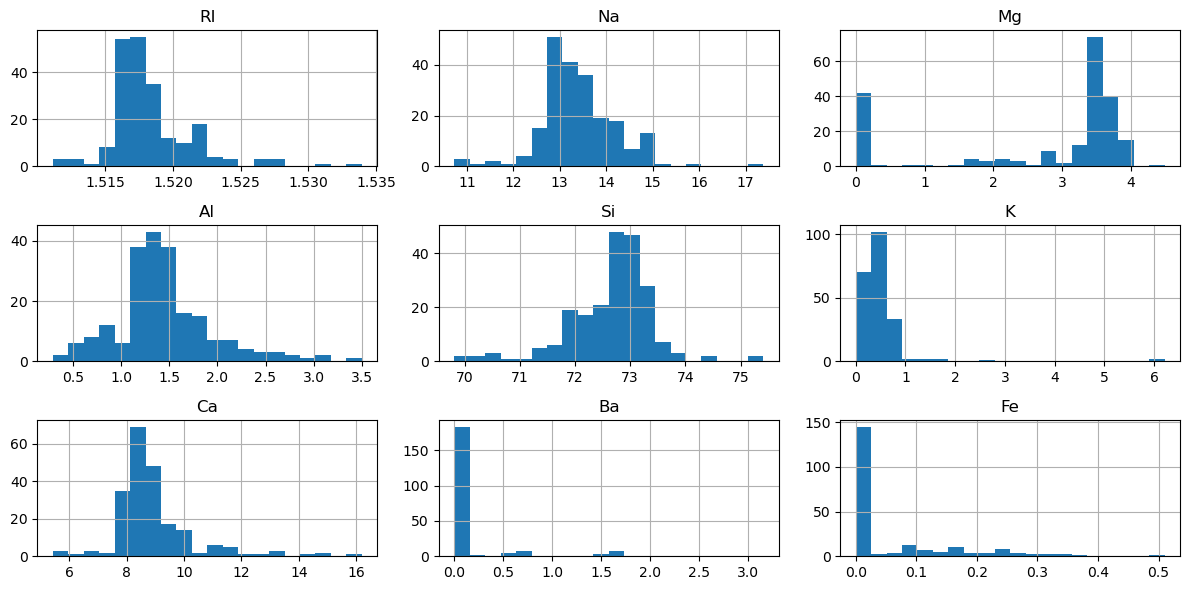

### Class Distribution

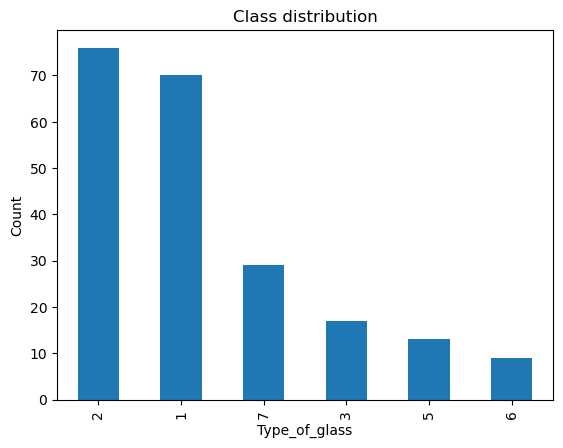

In [3]:
display(Markdown("### Initial Feature Preview"))
display(X.head())
display(Markdown("### Initial Target Preview"))
display(y.head())
display(Markdown("### Feature Missing-Value Check"))
display(X.isnull().sum())
display(Markdown("### Target Missing-Value Check"))
display(y.isnull().sum())
display(Markdown("### Feature Schema Summary"))
X.info()
display(Markdown("### Target Schema Summary"))
y.info()
display(Markdown("### Feature Distributions"))
X_num = X.select_dtypes(include=["float64", "int64"])
X_num.hist(figsize=(12,6), bins=20)
plt.tight_layout()
plt.show()
display(Markdown("### Class Distribution"))
y.value_counts().plot(kind="bar")
plt.ylabel("Count")
plt.title("Class distribution")
plt.show()

## Training Data Inspection

Create a stratified train-test split and inspect the training data used for preprocessing, model selection, and cross-validation.


### Initial Feature Preview

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
201,1.51653,11.95,0.00,1.19,75.18,2.70,8.93,0.0,0.00
38,1.52213,14.21,3.82,0.47,71.77,0.11,9.57,0.0,0.00
30,1.51768,12.65,3.56,1.30,73.08,0.61,8.69,0.0,0.14
48,1.52223,13.21,3.77,0.79,71.99,0.13,10.02,0.0,0.00
71,1.51848,13.64,3.87,1.27,71.96,0.54,8.32,0.0,0.32


### Initial Target Preview

201    7
38     1
30     1
48     1
71     2
Name: Type_of_glass, dtype: int64

### Feature Missing-Value Check

RI    0
Na    0
Mg    0
Al    0
Si    0
K     0
Ca    0
Ba    0
Fe    0
dtype: int64

### Target Missing-Value Check

np.int64(0)

### Feature Schema Summary

<class 'pandas.core.frame.DataFrame'>
Index: 171 entries, 201 to 178
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      171 non-null    float64
 1   Na      171 non-null    float64
 2   Mg      171 non-null    float64
 3   Al      171 non-null    float64
 4   Si      171 non-null    float64
 5   K       171 non-null    float64
 6   Ca      171 non-null    float64
 7   Ba      171 non-null    float64
 8   Fe      171 non-null    float64
dtypes: float64(9)
memory usage: 13.4 KB


### Target Schema Summary

<class 'pandas.core.series.Series'>
Index: 171 entries, 201 to 178
Series name: Type_of_glass
Non-Null Count  Dtype
--------------  -----
171 non-null    int64
dtypes: int64(1)
memory usage: 2.7 KB


### Feature Distributions

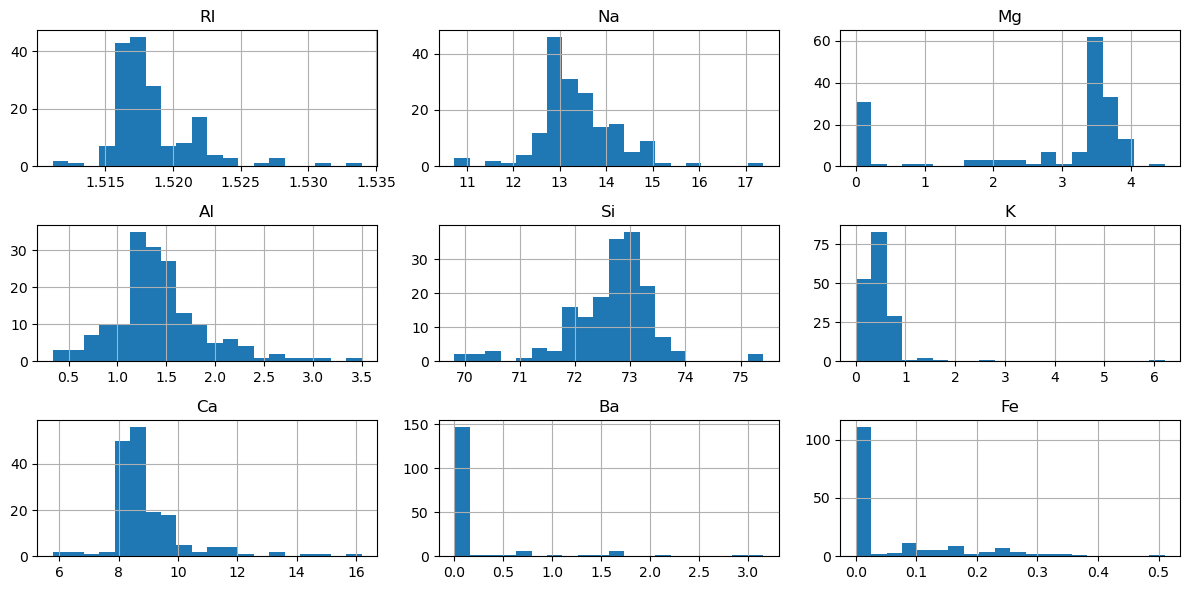

### Class Distribution

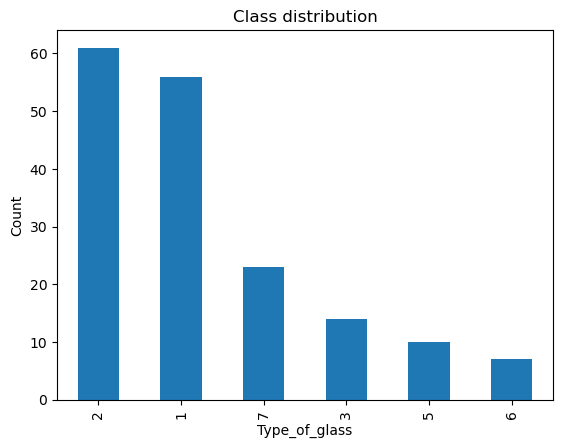

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

display(Markdown("### Initial Feature Preview"))
display(X_train.head())
display(Markdown("### Initial Target Preview"))
display(y_train.head())

display(Markdown("### Feature Missing-Value Check"))
display(X_train.isnull().sum())
display(Markdown("### Target Missing-Value Check"))
display(y_train.isnull().sum())

display(Markdown("### Feature Schema Summary"))
X_train.info()
display(Markdown("### Target Schema Summary"))
y_train.info()

display(Markdown("### Feature Distributions"))
X_train_num = X_train.select_dtypes(include=["float64", "int64"])


X_train_num.hist(figsize=(12, 6), bins=20)
plt.tight_layout()
plt.show()

display(Markdown("### Class Distribution"))
y_train.value_counts().plot(kind="bar")
plt.ylabel("Count")
plt.title("Class distribution")
plt.show()

## Preprocessing

Standardize the numerical features inside a `ColumnTransformer`. Keeping preprocessing inside the pipeline ensures that scaling is fitted only on the training fold during cross-validation.


## Model Selection

Compare decision-tree, bagging, random-forest, and gradient-boosting classifiers with randomized hyperparameter search. Because the target classes are imbalanced, selection uses `balanced_accuracy` with stratified cross-validation.


In [7]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", BaggingClassifier())
])

alphas = [0, 0.005, 0.01, 0.02, 0.05, 0.1]
depths = [3, 5, 8, 12, 20, None]
gb_depths = [2, 3, 4, 5]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_distributions = [
    {
        "model": [
            DecisionTreeClassifier(random_state=42, class_weight="balanced")
        ],
        "model__ccp_alpha": alphas,
        "model__max_depth": depths
    },
    {
        "model": [
            BaggingClassifier(
                estimator=DecisionTreeClassifier(random_state=42, class_weight="balanced"),
                random_state=42,
                n_jobs=-1
                )
            ],
        "model__n_estimators": randint(50, 401),
        "model__estimator__ccp_alpha": alphas,
        "model__estimator__max_depth": depths

    },
    {
        "model": [RandomForestClassifier(
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        )],
        "model__n_estimators": randint(50, 401),
        "model__max_depth": depths

    },
    {
        "model": [GradientBoostingClassifier(
            random_state=42
        )],
        "model__n_estimators": randint(50, 501),
        "model__learning_rate": loguniform(0.01, 0.3),
        "model__max_depth": gb_depths
    }
]

rnd = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    scoring="balanced_accuracy",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    n_iter=100
)


rnd.fit(X_train, y_train)

best_model = rnd.best_estimator_
display(Markdown("### Cross-Validation Scores"))
display(rnd.cv_results_["mean_test_score"])
display(Markdown("### Best Selected Pipeline"))
best_model

### Cross-Validation Scores

array([0.70191531, 0.69004662, 0.64128205, 0.69004662, 0.71714064,
       0.68092852, 0.61174048, 0.62609557, 0.68092852, 0.69820124,
       0.69253302, 0.60008547, 0.67803807, 0.59247086, 0.70447941,
       0.69509713, 0.57840715, 0.68092852, 0.59221834, 0.69820124,
       0.71714064, 0.61174048, 0.70909868, 0.69413753, 0.62007382,
       0.70447941, 0.61426573, 0.6059324 , 0.61772339, 0.57786325,
       0.6577195 , 0.69202797, 0.71714064, 0.70616939, 0.68925019,
       0.68810023, 0.69505828, 0.63165113, 0.67486791, 0.56747086,
       0.698885  , 0.64128205, 0.70447941, 0.69413753, 0.61170163,
       0.68874514, 0.71714064, 0.64128205, 0.71714064, 0.6059324 ,
       0.57815462, 0.64128205, 0.62050117, 0.60818182, 0.70426185,
       0.72395882, 0.69824009, 0.70494561, 0.67966589, 0.69668609,
       0.62353147, 0.69052448, 0.61960761, 0.64128205, 0.43148796,
       0.70249417, 0.6577195 , 0.698885  , 0.71714064, 0.60055167,
       0.68726884, 0.68925019, 0.6637568 , 0.60616162, 0.60635

### Best Selected Pipeline

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,estimator,DecisionTreeC...ndom_state=42)
,n_estimators,332
,max_samples,1.0
,max_features,1.0


## Evaluation

Evaluate the selected pipeline on the held-out test set with classification metrics and the confusion matrix.


Accuracy: 0.5813953488372093

Classification report:
              precision    recall  f1-score   support

           1       0.58      0.50      0.54        14
           2       0.67      0.40      0.50        15
           3       0.25      0.67      0.36         3
           5       0.60      1.00      0.75         3
           6       0.50      1.00      0.67         2
           7       1.00      0.83      0.91         6

    accuracy                           0.58        43
   macro avg       0.60      0.73      0.62        43
weighted avg       0.64      0.58      0.59        43

Confusion matrix:



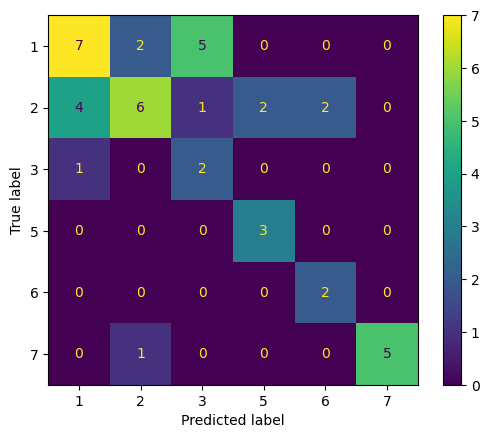

In [8]:
evaluate_classification(best_model, X_test, y_test)